In [ ]:
!pip install kagglehub -q

In [ ]:
import kagglehub, os, random, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.applications import EfficientNetB0

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
path = kagglehub.dataset_download("tushar5harma/plant-village-dataset-updated")
print("Dataset path:", path)
BASE_DIR = path

Using Colab cache for faster access to the 'plant-village-dataset-updated' dataset.
Dataset path: /kaggle/input/plant-village-dataset-updated


In [ ]:
all_train_dirs = []
all_val_dirs   = []
all_test_dirs  = []
all_class_names = set()

for plant_folder in sorted(os.listdir(BASE_DIR)):
    plant_path = os.path.join(BASE_DIR, plant_folder)
    if not os.path.isdir(plant_path):
        continue
    train_path = os.path.join(plant_path, 'Train')
    val_path   = os.path.join(plant_path, 'Val')
    test_path  = os.path.join(plant_path, 'Test')

    if os.path.isdir(train_path):
        all_train_dirs.append(train_path)
        for disease_folder in sorted(os.listdir(train_path)):
            if os.path.isdir(os.path.join(train_path, disease_folder)):
                all_class_names.add(disease_folder)
    if os.path.isdir(val_path):
        all_val_dirs.append(val_path)
    if os.path.isdir(test_path):
        all_test_dirs.append(test_path)

CLASS_NAMES = sorted(list(all_class_names))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Jumlah kelas   : {NUM_CLASSES}")
print(f"Contoh kelas   : {CLASS_NAMES[:5]}")
print(f"Plant folders  : {len(all_train_dirs)}")

Jumlah kelas   : 16
Contoh kelas   : ['Apple Scab', 'Bacterial Spot', 'Black Rot', 'Cedar Apple Rust', 'Cercospora Leaf Spot']
Plant folders  : 9


In [ ]:
import shutil

FLAT_TRAIN = '/content/flat_train'
FLAT_VAL   = '/content/flat_val'
FLAT_TEST  = '/content/flat_test'

for flat_dir, source_dirs in [
    (FLAT_TRAIN, all_train_dirs),
    (FLAT_VAL,   all_val_dirs),
    (FLAT_TEST,  all_test_dirs)
]:
    if os.path.exists(flat_dir):
        shutil.rmtree(flat_dir)
    os.makedirs(flat_dir)

    for src in source_dirs:
        for disease_folder in sorted(os.listdir(src)):
            disease_path = os.path.join(src, disease_folder)
            if os.path.isdir(disease_path):
                dst = os.path.join(flat_dir, disease_folder)
                if not os.path.exists(dst):
                    os.symlink(disease_path, dst)

print(f"flat_train kelas : {len(os.listdir(FLAT_TRAIN))}")
print(f"flat_val kelas   : {len(os.listdir(FLAT_VAL))}")
print(f"flat_test kelas  : {len(os.listdir(FLAT_TEST))}")

flat_train kelas : 16
flat_val kelas   : 16
flat_test kelas  : 16


In [ ]:
total_train = sum(len(os.listdir(os.path.join(FLAT_TRAIN, c)))
                  for c in os.listdir(FLAT_TRAIN)
                  if os.path.isdir(os.path.join(FLAT_TRAIN, c)))
total_val   = sum(len(os.listdir(os.path.join(FLAT_VAL, c)))
                  for c in os.listdir(FLAT_VAL)
                  if os.path.isdir(os.path.join(FLAT_VAL, c)))
total_test  = sum(len(os.listdir(os.path.join(FLAT_TEST, c)))
                  for c in os.listdir(FLAT_TEST)
                  if os.path.isdir(os.path.join(FLAT_TEST, c)))
print(f"\nTotal gambar train : {total_train}")
print(f"Total gambar val   : {total_val}")
print(f"Total gambar test  : {total_test}")


Total gambar train : 29825
Total gambar val   : 6705
Total gambar test  : 752


In [ ]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS     = 5
SEED       = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"Jumlah kelas  : {NUM_CLASSES}")
print(f"Ukuran gambar : {IMG_SIZE}")
print(f"Batch size    : {BATCH_SIZE}")

Jumlah kelas  : 16
Ukuran gambar : (128, 128)
Batch size    : 32


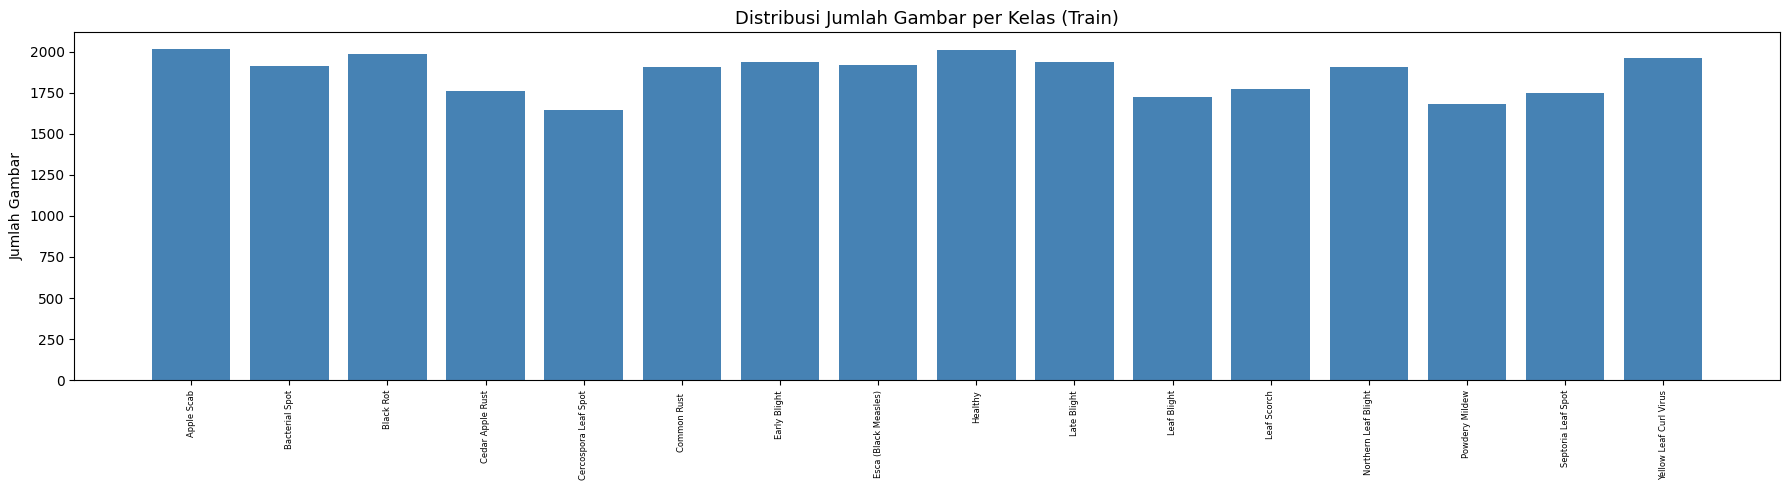

Total : 29825
Rata  : 1864
Min   : 1642
Max   : 2016


In [ ]:
class_counts = {}
for cls in sorted(os.listdir(FLAT_TRAIN)):
    cls_path = os.path.join(FLAT_TRAIN, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

plt.figure(figsize=(18, 5))
plt.bar(range(len(class_counts)), list(class_counts.values()), color='steelblue')
plt.xticks(range(len(class_counts)), list(class_counts.keys()),
           rotation=90, fontsize=6)
plt.title("Distribusi Jumlah Gambar per Kelas (Train)", fontsize=13)
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.show()

print(f"Total : {sum(class_counts.values())}")
print(f"Rata  : {int(np.mean(list(class_counts.values())))}")
print(f"Min   : {min(class_counts.values())}")
print(f"Max   : {max(class_counts.values())}")

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    FLAT_TRAIN,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    FLAT_VAL,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    FLAT_TEST,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED,
    shuffle=False
)

print(f"\nTraining samples : {train_gen.samples}")
print(f"Val samples      : {val_gen.samples}")
print(f"Test samples     : {test_gen.samples}")
print(f"Jumlah kelas     : {train_gen.num_classes}")

Found 29827 images belonging to 16 classes.
Found 6705 images belonging to 16 classes.
Found 755 images belonging to 16 classes.

Training samples : 29827
Val samples      : 6705
Test samples     : 755
Jumlah kelas     : 16


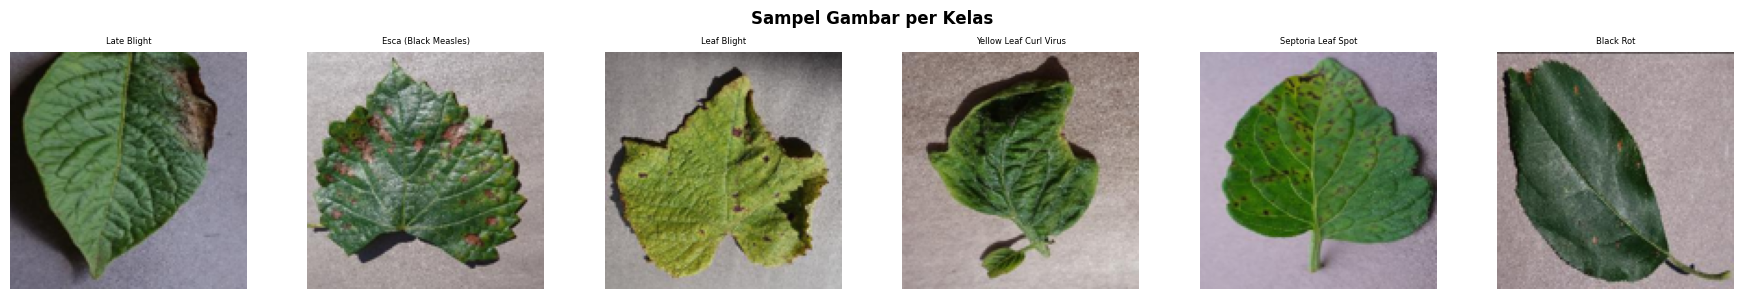

In [ ]:
from PIL import Image as PILImage

def show_sample_images(flat_dir, n_classes=6):
    cls_list = sorted(os.listdir(flat_dir))
    selected = random.sample(cls_list, min(n_classes, len(cls_list)))
    fig, axes = plt.subplots(1, len(selected), figsize=(3*len(selected), 3))
    for ax, cls in zip(axes, selected):
        folder = os.path.join(flat_dir, cls)
        img_file = random.choice(os.listdir(folder))
        img = PILImage.open(os.path.join(folder, img_file)).resize(IMG_SIZE)
        ax.imshow(img)
        ax.set_title(cls.replace('___', '\n'), fontsize=6)
        ax.axis('off')
    plt.suptitle("Sampel Gambar per Kelas", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_images(FLAT_TRAIN)

# Arsitektur CNN Sederhana

In [ ]:
def build_simple_cnn(input_shape, num_classes):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),

        # Classifier Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name="SimpleCNN")
    return model

model_cnn = build_simple_cnn((*IMG_SIZE, 3), NUM_CLASSES)
model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 853,168 (3.25 MB)

 Trainable params: 851,184 (3.25 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_cnn_simple.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Model siap dilatih!")

Model siap dilatih!


In [ ]:
print("="*60)
print("TRAINING CNN SEDERHANA — PlantVillage")
print("="*60)

history_cnn = model_cnn.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print(f"\nBest val_accuracy: {max(history_cnn.history['val_accuracy'])*100:.2f}%")

TRAINING CNN SEDERHANA — PlantVillage
Epoch 1/5
933/933 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.4529 - loss: 1.8305 - top3_acc: 0.7375
Epoch 1: val_accuracy improved from None to 0.42774, saving model to best_cnn_simple.keras

Epoch 1: finished saving model to best_cnn_simple.keras
933/933 ━━━━━━━━━━━━━━━━━━━━ 300s 321ms/step - accuracy: 0.5880 - loss: 1.3045 - top3_acc: 0.8557 - val_accuracy: 0.4277 - val_loss: 3.2600 - val_top3_acc: 0.7383 - learning_rate: 0.0010
Epoch 2/5
933/933 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.7752 - loss: 0.6645 - top3_acc: 0.9603
Epoch 2: val_accuracy improved from 0.42774 to 0.78001, saving model to best_cnn_simple.keras

Epoch 2: finished saving model to best_cnn_simple.keras
933/933 ━━━━━━━━━━━━━━━━━━━━ 206s 221ms/step - accuracy: 0.8208 - loss: 0.5329 - top3_acc: 0.9726 - val_accuracy: 0.7800 - val_loss: 0.8672 - val_top3_acc: 0.9389 - learning_rate: 0.0010
Epoch 3/5
933/933 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.8863 - los

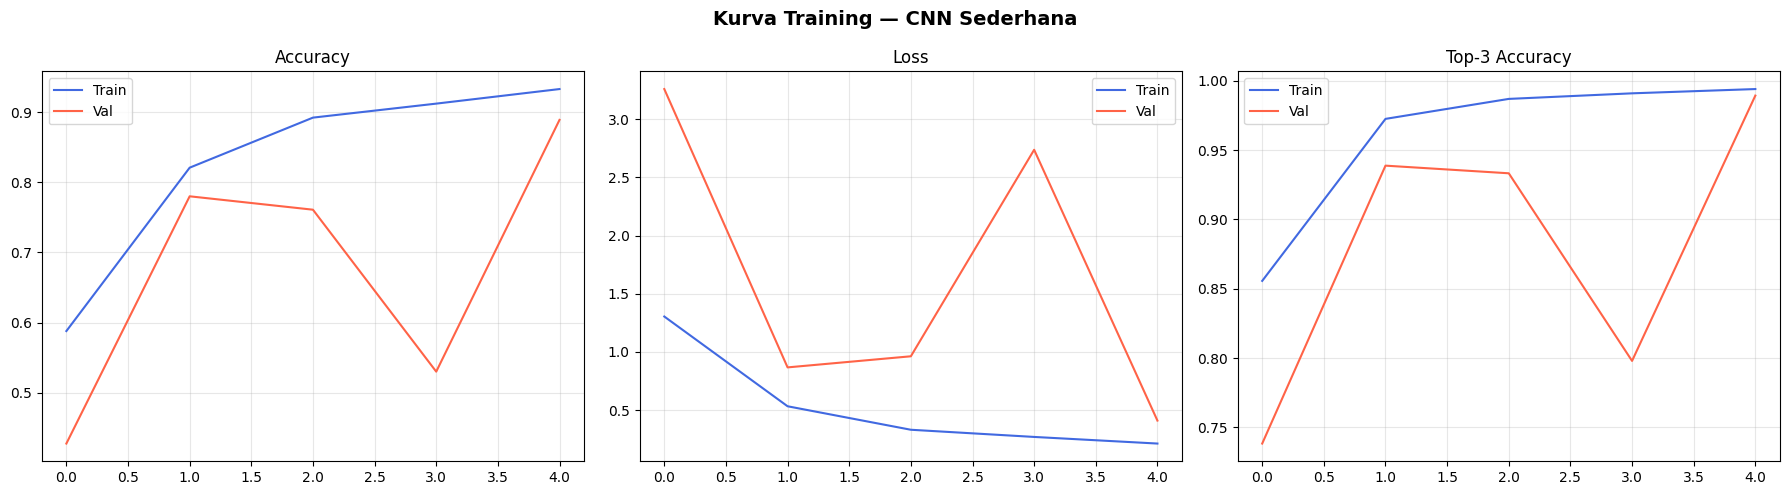

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Kurva Training — CNN Sederhana", fontsize=14, fontweight='bold')

axes[0].plot(history_cnn.history['accuracy'],     label='Train', color='royalblue')
axes[0].plot(history_cnn.history['val_accuracy'], label='Val',   color='tomato')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history['loss'],     label='Train', color='royalblue')
axes[1].plot(history_cnn.history['val_loss'], label='Val',   color='tomato')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history_cnn.history['top3_acc'],     label='Train', color='royalblue')
axes[2].plot(history_cnn.history['val_top3_acc'], label='Val',   color='tomato')
axes[2].set_title('Top-3 Accuracy'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curve_cnn.png', dpi=150)
plt.show()

In [ ]:
test_gen.reset()
results = model_cnn.evaluate(test_gen, verbose=1)

print("\n" + "="*50)
print("HASIL EVALUASI CNN SEDERHANA — TEST SET")
print("="*50)
for name, val in zip(model_cnn.metrics_names, results):
    print(f"  {name:<20} : {val:.4f}")
print("="*50)

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.8993 - loss: 0.3952 - top3_acc: 0.9907

HASIL EVALUASI CNN SEDERHANA — TEST SET
  loss                 : 0.3952
  compile_metrics      : 0.8993


In [ ]:
test_gen.reset()
y_pred_probs = model_cnn.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes
class_names  = list(test_gen.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred,
                             target_names=class_names, digits=4))

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step

Classification Report:
                        precision    recall  f1-score   support

            Apple Scab     1.0000    0.8627    0.9263        51
        Bacterial Spot     0.9688    0.6458    0.7750        48
             Black Rot     0.9524    0.8000    0.8696        50
      Cedar Apple Rust     1.0000    0.9545    0.9767        44
  Cercospora Leaf Spot     0.8750    0.9333    0.9032        45
          Common Rust      0.9057    1.0000    0.9505        48
          Early Blight     0.6901    1.0000    0.8167        49
  Esca (Black Measles)     0.9412    1.0000    0.9697        48
               Healthy     0.6800    1.0000    0.8095        51
           Late Blight     0.8727    0.9796    0.9231        49
           Leaf Blight     0.9348    1.0000    0.9663        43
           Leaf Scorch     0.9706    0.7333    0.8354        45
  Northern Leaf Blight     1.0000    0.8125    0.8966        48
        Powdery Mildew     1.0000    1.

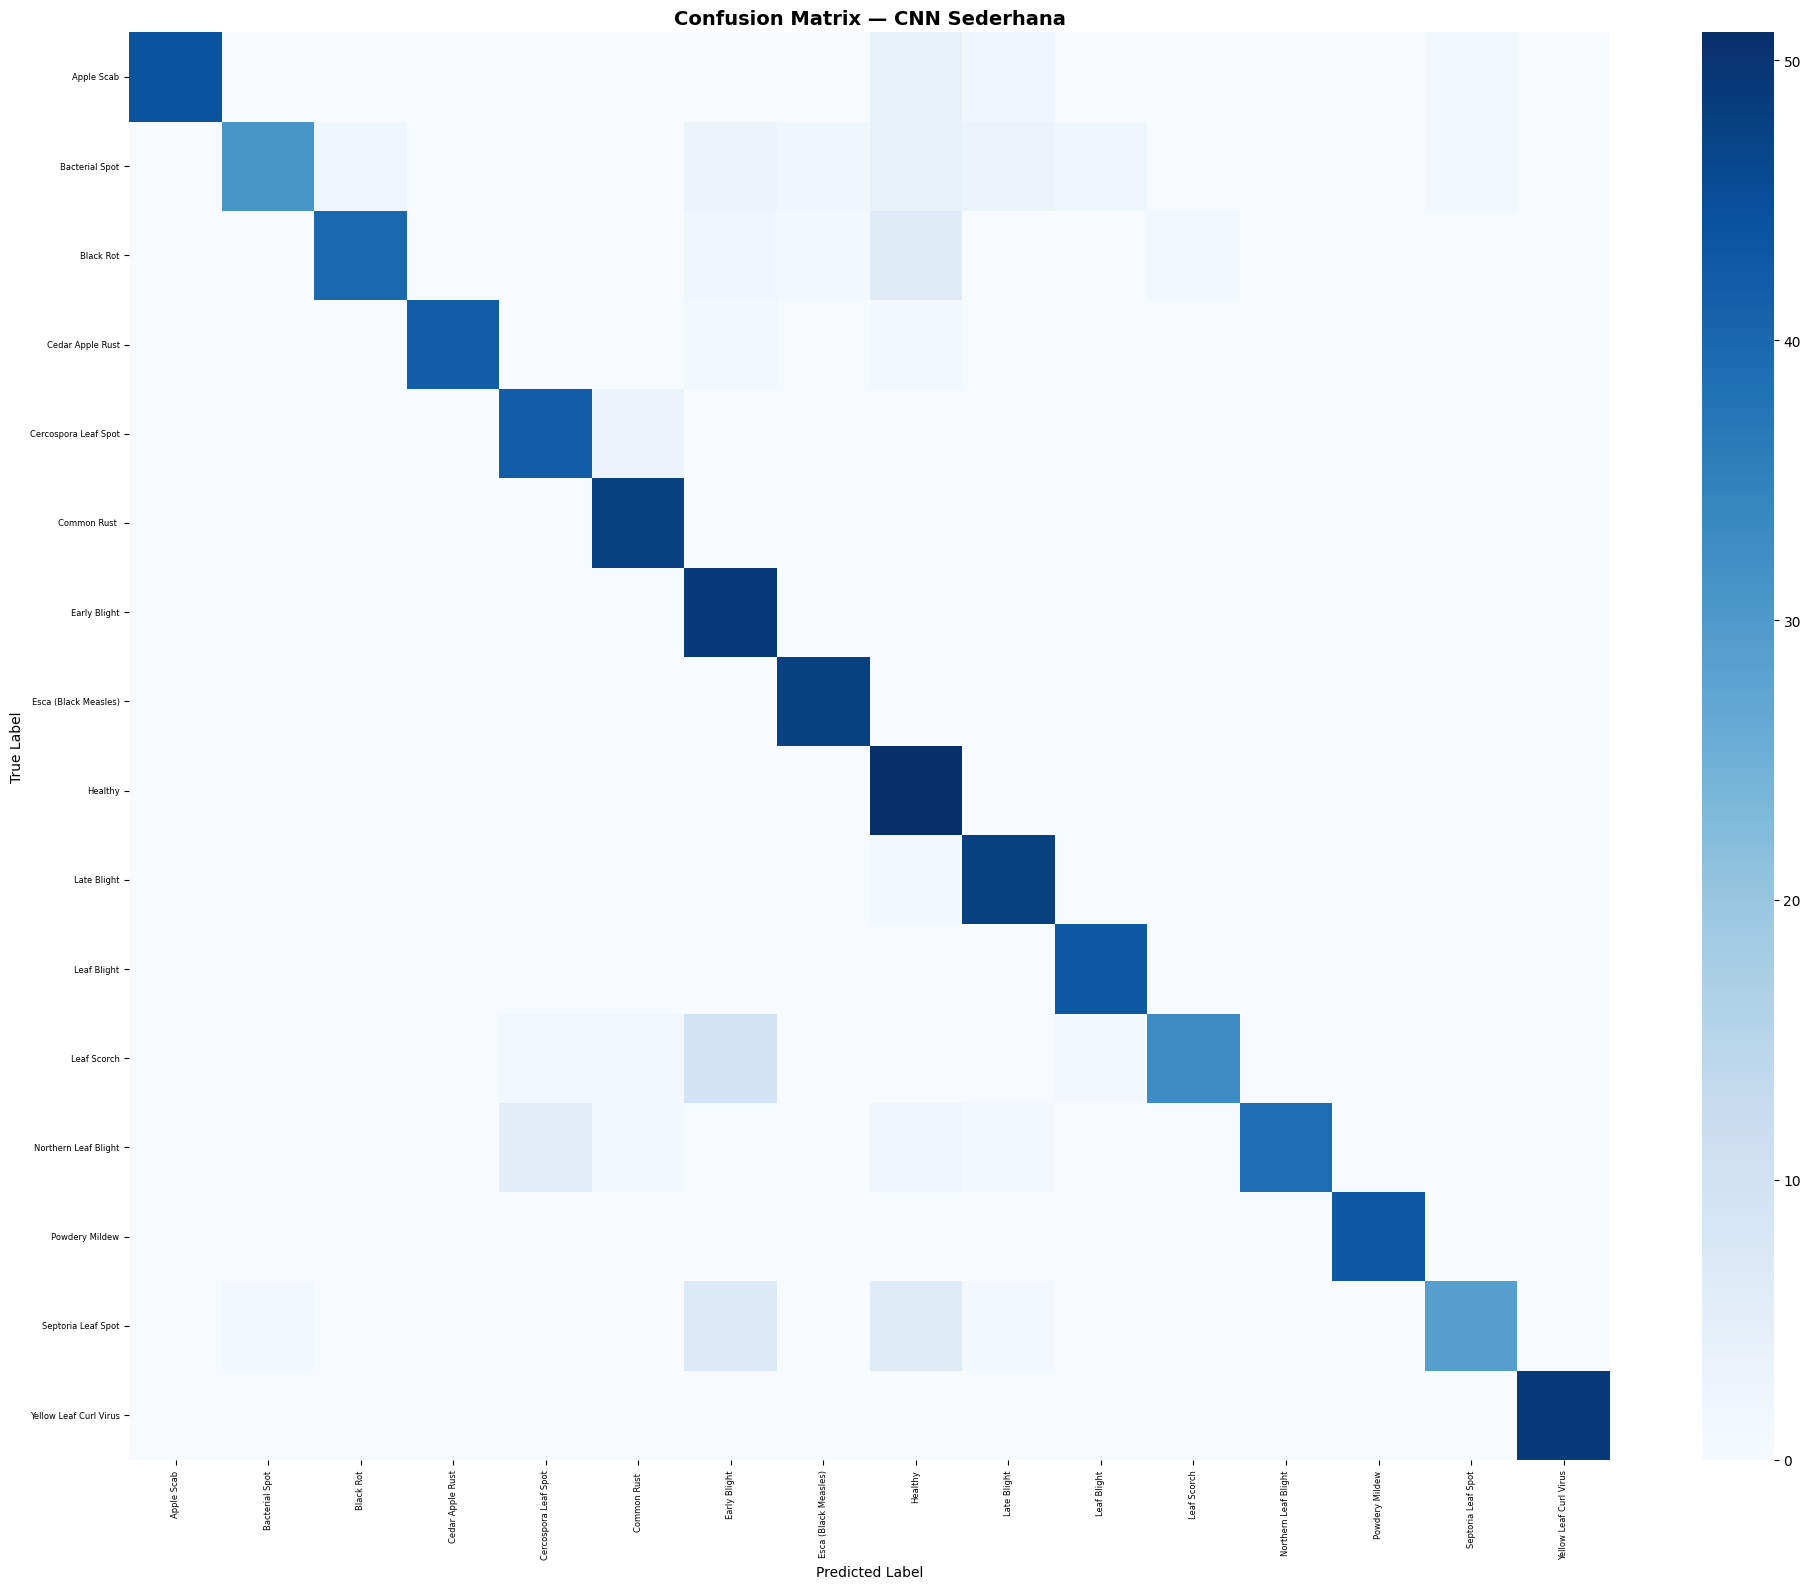

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — CNN Sederhana', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=90, fontsize=6); plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig('confusion_matrix_cnn.png', dpi=150)
plt.show()


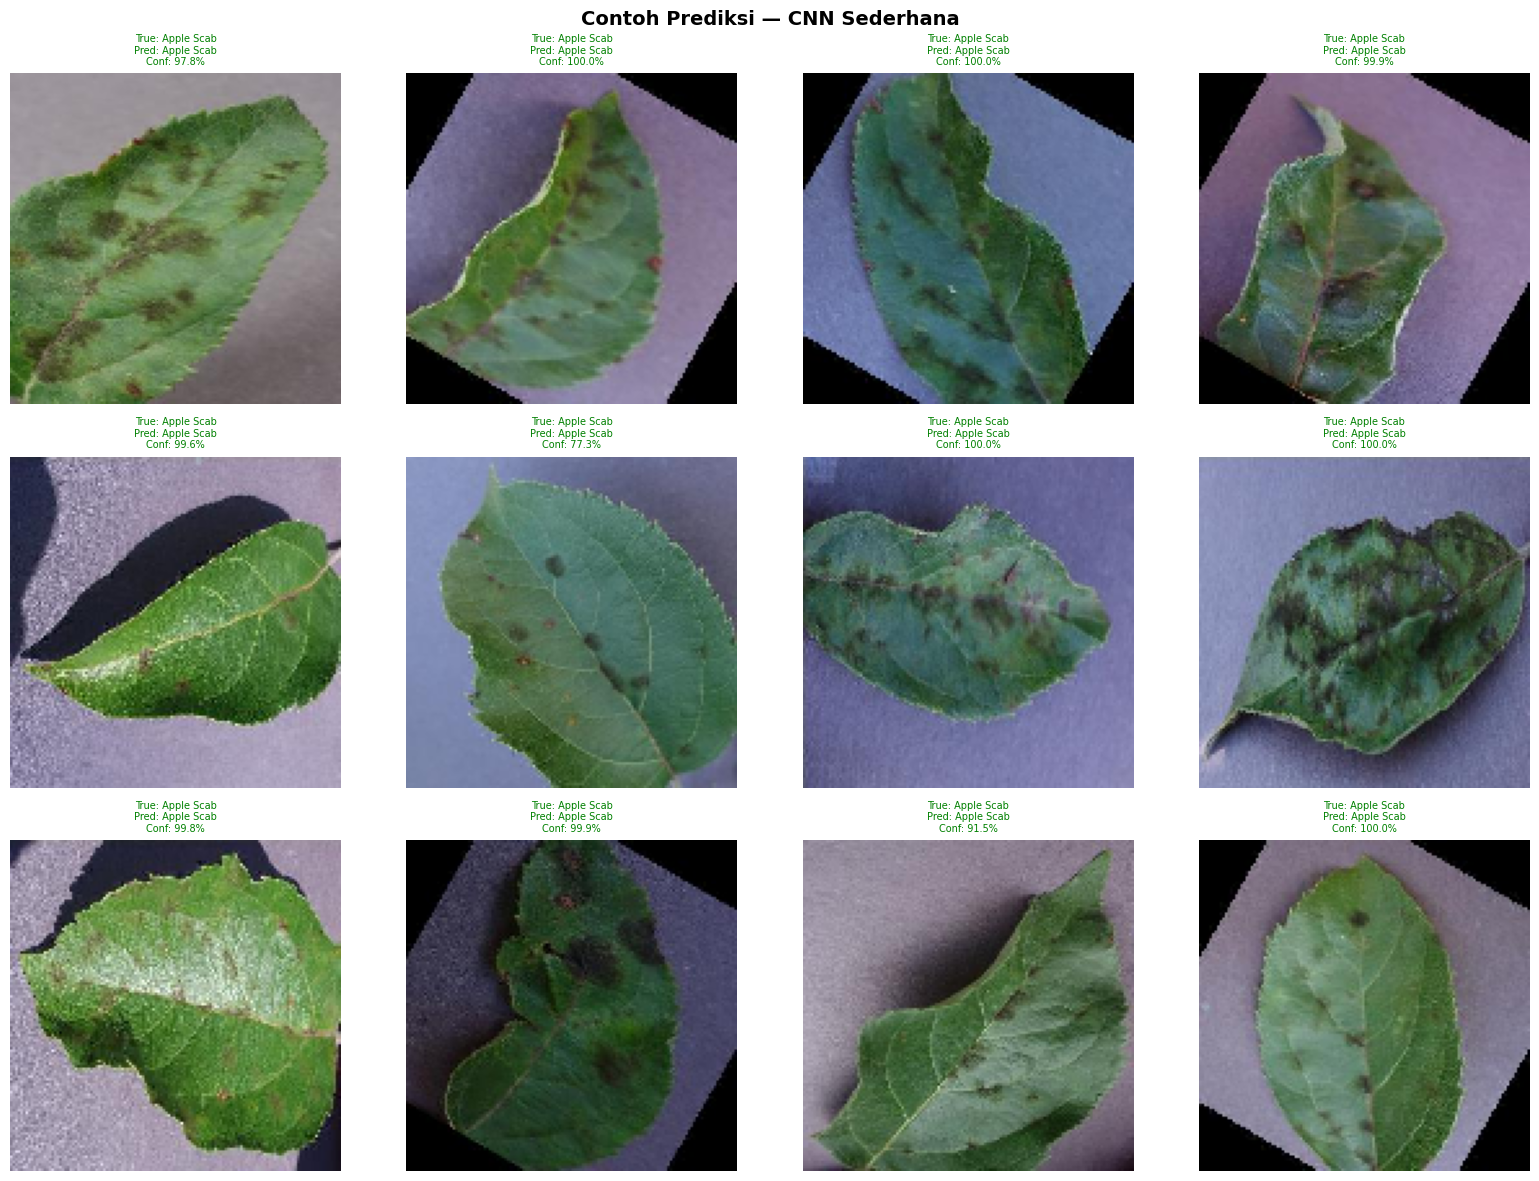

In [ ]:
def show_predictions(generator, model, class_names, n=12):
    generator.reset()
    x_batch, y_batch = next(generator)
    preds = model.predict(x_batch[:n], verbose=0)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle("Contoh Prediksi — CNN Sederhana", fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i >= n: break
        ax.imshow(x_batch[i])
        true_cls = class_names[np.argmax(y_batch[i])]
        pred_cls = class_names[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        color    = 'green' if true_cls == pred_cls else 'red'
        ax.set_title(
            f"True: {true_cls.split('___')[-1]}\nPred: {pred_cls.split('___')[-1]}\nConf: {conf:.1f}%",
            fontsize=7, color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('predictions_cnn.png', dpi=150)
    plt.show()

show_predictions(test_gen, model_cnn, class_names)

In [ ]:
model_cnn.save('model_cnn_sederhana_plantvillage.keras')
print("Model tersimpan!")

# Simpan hasil ke CSV untuk perbandingan akhir
import pandas as pd

test_loss = results[0]
test_acc  = results[1]
test_top3 = results[2]

df_results = pd.DataFrame([{
    'Model'     : 'CNN Sederhana',
    'Test Loss' : round(test_loss, 4),
    'Test Acc'  : round(test_acc, 4),
    'Top3 Acc'  : round(test_top3, 4)
}])
df_results.to_csv('results_cnn_sederhana.csv', index=False)

print("\n" + "="*55)
print("RINGKASAN — CNN SEDERHANA")
print("="*55)
print(f"  Dataset      : PlantVillage ({NUM_CLASSES} kelas)")
print(f"  Arsitektur   : Custom CNN (4 Conv Block)")
print(f"  Input size   : {IMG_SIZE}")
print(f"  Parameters   : {model_cnn.count_params():,}")
print(f"  Test Loss    : {test_loss:.4f}")
print(f"  Test Acc     : {test_acc*100:.2f}%")
print(f"  Top-3 Acc    : {test_top3*100:.2f}%")

Model tersimpan!

RINGKASAN — CNN SEDERHANA
  Dataset      : PlantVillage (16 kelas)
  Arsitektur   : Custom CNN (4 Conv Block)
  Input size   : (128, 128)
  Parameters   : 853,168
  Test Loss    : 0.3952
  Test Acc     : 89.93%
  Top-3 Acc    : 99.07%
